# THAI-MOD Full Pipeline

## What this notebook covers
- Dataset aggregation from all 8 documented datasets
- Text preprocessing for Thai + English comments
- Stratified train/test split
- Traditional ML baselines with TF-IDF features
- Transformer model comparison
- Confusion matrix for each model
- Final inference helper aligned with the system pipeline


## System Pipeline From The Docs

The notebook follows the project docs:
1. Aggregate multilingual toxicity datasets and deduplicate by text.
2. Clean text by removing URLs, normalizing emojis, and lowercasing English characters.
3. Map labels into binary classes: `toxic = 1`, `non-toxic = 0`.
4. Split data with stratification to preserve class balance.
5. Train traditional TF-IDF baselines and transformer-based models.
6. Evaluate with recall-oriented metrics and confusion matrices.
7. Provide a final decision-support inference helper for moderators.

The docs emphasize recall on the toxic class because false negatives are more harmful than false positives in moderation.


In [1]:
import gc
import re
import string
import warnings
from pathlib import Path

import emoji
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import json
import joblib
import torch.nn.functional as F
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler
from pythainlp.tokenize import word_tokenize
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    fbeta_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    CamembertTokenizer,
    get_linear_schedule_with_warmup,
)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", None)
sns.set_theme(style="whitegrid")

In [2]:
ROOT = Path.cwd()
DATASET_FILES = [ROOT / "datasets" / f"dataset{i}.csv" for i in range(1, 9)]
MODEL_CACHE_DIR = ROOT / "models"
BASELINE_CACHE_DIR = MODEL_CACHE_DIR / "baselines"
TRANSFORMER_CACHE_DIR = MODEL_CACHE_DIR / "transformers"
BASELINE_CACHE_DIR.mkdir(parents=True, exist_ok=True)
TRANSFORMER_CACHE_DIR.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42
TEST_SIZE = 0.2

MAX_FEATURES = 10_000
NGRAM_RANGE = (1, 2)
CLASS_NAMES = ["non-toxic", "toxic"]
TRANSFORMER_THRESHOLD = 0.4

EPOCHS = 3
LEARNING_RATE = 2e-5
WARMUP_STEPS = 100

TRANSFORMER_MODELS = {
    "WangchanBERTa": "airesearch/wangchanberta-base-att-spm-uncased",
    "PhayaThaiBERT": "clicknext/phayathaibert",
}

ROOT, DATASET_FILES[:2], TRANSFORMER_MODELS

(PosixPath('/Users/tkdxz/Documents/CEDT/Sem2_2025/2110555_SEML/THAI-MOD-Multilingual-Online-Toxicity-Detection-System'),
 [PosixPath('/Users/tkdxz/Documents/CEDT/Sem2_2025/2110555_SEML/THAI-MOD-Multilingual-Online-Toxicity-Detection-System/datasets/dataset1.csv'),
  PosixPath('/Users/tkdxz/Documents/CEDT/Sem2_2025/2110555_SEML/THAI-MOD-Multilingual-Online-Toxicity-Detection-System/datasets/dataset2.csv')],
 {'WangchanBERTa': 'airesearch/wangchanberta-base-att-spm-uncased',
  'PhayaThaiBERT': 'clicknext/phayathaibert'})

In [3]:
def clean_text(text):
    if pd.isna(text):
        return text

    text = str(text)
    text = re.sub(
        r"http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+",
        "",
        text,
    )
    text = re.sub(
        r"www\.(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+",
        "",
        text,
    )
    text = emoji.demojize(text, language="en")
    return text.strip()


def lowercase_english(text):
    if pd.isna(text):
        return text

    result = []
    for char in str(text):
        result.append(char.lower() if ord(char) < 128 else char)
    return "".join(result)


def calculate_thai_length(text):
    if pd.isna(text):
        return 0
    return len(word_tokenize(str(text), engine="newmm"))


def prepare_dataset(dataset_file):
    df = pd.read_csv(dataset_file).copy()
    df = df.dropna(subset=["category", "texts"])
    df["texts"] = df["texts"].apply(clean_text).apply(lowercase_english)
    df = df[df["texts"].str.strip() != ""].copy()
    df["category"] = df["category"].replace({"pos": "neu"})
    df["category"] = df["category"].map({"neg": 1, "neu": 0})
    df = df.dropna(subset=["category"]).copy()
    df["category"] = df["category"].astype(int)
    df["length"] = df["texts"].apply(calculate_thai_length)
    df["source"] = Path(dataset_file).name
    return df[["texts", "category", "length", "source"]]


def load_full_dataset(dataset_files):
    prepared = [prepare_dataset(path) for path in dataset_files]
    combined = pd.concat(prepared, ignore_index=True)
    before_dedup = len(combined)
    combined = combined.drop_duplicates(subset=["texts"], keep="first").reset_index(drop=True)
    print(f"Rows before deduplication: {before_dedup:,}")
    print(f"Rows after deduplication:  {len(combined):,}")
    print(f"Label distribution: {combined['category'].value_counts(normalize=True).round(4).to_dict()}")
    return combined


combined_df = load_full_dataset(DATASET_FILES)
combined_df.head()

Rows before deduplication: 233,922
Rows after deduplication:  233,558
Label distribution: {0: 0.7655, 1: 0.2345}


,texts,category,length,source
0,อิเหี้ยออมทำกูอยากกินเอ็มเค,1,9,dataset1.csv
1,เน็ตควายมากกูพูดจริงเสียดายตังค์ที่ติดตั้งเน็ตโครตห่วยยิ่งดึกๆเน็ตยิ่งห่วยตอนมาติดตั้งใหม่ๆก็ดีนานๆไปเเย่ขึ้นเรื่อยๆกากกว่าเน็ตค่ายอื่นอ่ะบอกจริงไม่สนหรอกว่าจะเป็นเด็กเเล้วเม้นด่าเเบบนี้ เเต่นี้หาตังค์จ่ายค่าเน็ตมาตลอดเหนื่อยน่ะเล่นเกมส์ไปเดี่ยวก็หายกากเกินติดตั้งโปรพิเศษ100mเเต่พอวัดดูปล่อยไม่ถึงเท่าที่ตกลงกันไว้พอโทรไปเเจ้งก็ปล่อยมาเต็มไม่กี่วันก็เหมื่อนเดิมใบเเจ้งก็มาย้อนหลัง3เดือนทุกครั้งห่วยไปน่ะบางทีโปร100m/700 กว่าบาทเเต่คุณภาพเเย่เสียดายตังค์,1,127,dataset1.csv
2,เหล้าเบลล์รสชาติเหี้ยสุด จะไม่แดกอีกละ,1,11,dataset1.csv
3,ลิปมันของเเบร์น mistine ราคากลาง ๆ ไม่แพงมาก ราคาสามารถเอื้อมถึงได้ #lashesactivity,1,23,dataset1.csv
4,ทำไมมันไม่มีโปรให้เร๊าาาาาา,1,7,dataset1.csv


In [4]:
summary_df = pd.DataFrame(
    {
        "rows": [len(combined_df)],
        "toxic_count": [int(combined_df["category"].sum())],
        "non_toxic_count": [int((combined_df["category"] == 0).sum())],
        "avg_length": [round(combined_df["length"].mean(), 2)],
        "median_length": [round(combined_df["length"].median(), 2)],
    }
)
summary_df

,rows,toxic_count,non_toxic_count,avg_length,median_length
0,233558,54758,178800,107.06,46.0


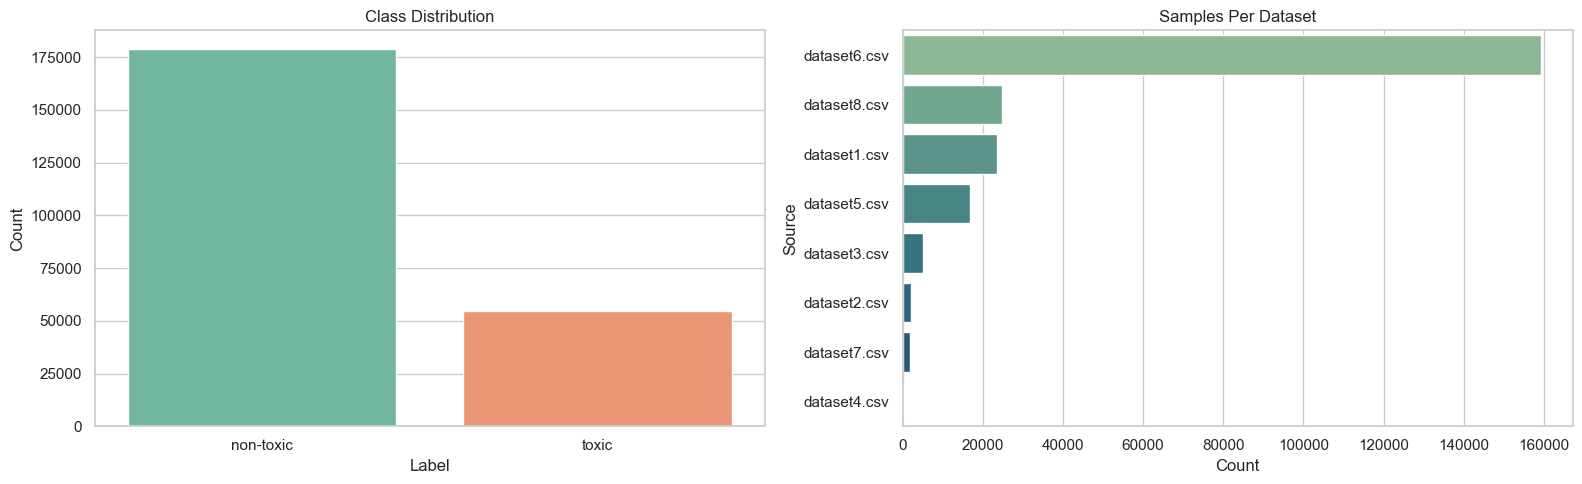

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

class_counts = combined_df["category"].map({0: "non-toxic", 1: "toxic"}).value_counts()
sns.barplot(x=class_counts.index, y=class_counts.values, ax=axes[0], palette="Set2")
axes[0].set_title("Class Distribution")
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Count")

source_counts = combined_df["source"].value_counts().sort_values(ascending=False)
sns.barplot(x=source_counts.values, y=source_counts.index, ax=axes[1], palette="crest")
axes[1].set_title("Samples Per Dataset")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("Source")

plt.tight_layout()
plt.show()

In [6]:
X = combined_df["texts"]
y = combined_df["category"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape: ", X_test.shape, y_test.shape)
print("Train class distribution:", y_train.value_counts(normalize=True).round(4).to_dict())
print("Test class distribution: ", y_test.value_counts(normalize=True).round(4).to_dict())

Train shape: (186846,) (186846,)
Test shape:  (46712,) (46712,)
Train class distribution: {0: 0.7656, 1: 0.2344}
Test class distribution:  {0: 0.7655, 1: 0.2345}


## Traditional ML Models

- Multinomial Naive Bayes
- Linear SVC
- Logistic Regression
- XGBoost

TF-IDF features with Thai tokenization are used as the classical feature pipeline.


In [7]:
def get_safe_name(name):
    return name.lower().replace(" ", "_").replace("/", "_").replace("-", "_")


def process_text(text):
    nopunc = "".join(char for char in str(text) if char not in string.punctuation)
    return [token for token in word_tokenize(nopunc, engine="newmm") if token and not token.isspace()]


def build_classical_models():
    return {
        "Naive Bayes": Pipeline(
            [
                ("vect", CountVectorizer(tokenizer=process_text, ngram_range=NGRAM_RANGE, token_pattern=None, min_df=2, max_features=MAX_FEATURES)),
                ("tfidf", TfidfTransformer()),
                ("clf", MultinomialNB(alpha=0.001)),
            ]
        ),
        "Linear SVC": Pipeline(
            [
                ("vect", CountVectorizer(tokenizer=process_text, ngram_range=NGRAM_RANGE, token_pattern=None, min_df=2, max_features=MAX_FEATURES)),
                ("tfidf", TfidfTransformer()),
                ("clf", LinearSVC()),
            ]
        ),
        "Logistic Regression": Pipeline(
            [
                ("vect", CountVectorizer(tokenizer=process_text, ngram_range=NGRAM_RANGE, token_pattern=None)),
                ("tfidf", TfidfTransformer()),
                ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
            ]
        ),
        "XGBoost": Pipeline(
            [
                ("vect", CountVectorizer(tokenizer=process_text, ngram_range=NGRAM_RANGE, token_pattern=None)),
                ("tfidf", TfidfTransformer()),
                ("clf", XGBClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1, eval_metric="logloss")),
            ]
        ),
    }


In [8]:
def compute_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0),
        "F2-Score": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
    }


def plot_confusion_matrices(results, title, cols=2):
    rows = int(np.ceil(len(results) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, result in zip(axes, results):
        sns.heatmap(
            result["confusion_matrix"],
            annot=True,
            fmt="d",
            cmap="Blues",
            cbar=False,
            ax=ax,
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES,
        )
        ax.set_title(result["Model"])
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")

    for ax in axes[len(results):]:
        ax.axis("off")

    fig.suptitle(title, fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()


def evaluate_classical_models(models, X_train, X_test, y_train, y_test):
    results = []
    fitted_models = {}

    for model_name, model in models.items():
        print(f"Training {model_name}...")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        metrics = compute_metrics(y_test, y_pred)
        metrics["Model"] = model_name
        metrics["confusion_matrix"] = confusion_matrix(y_test, y_pred)
        results.append(metrics)
        fitted_models[model_name] = model

        print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, zero_division=0))

    return results, fitted_models


In [ ]:
def train_or_load_baseline_model(
    model_name,
    model,
    X_train,
    y_train,
    X_test,
    y_test,
    force_retrain=False,
):
    safe_name = get_safe_name(model_name)
    model_path = BASELINE_CACHE_DIR / f"{safe_name}.joblib"
    meta_path = BASELINE_CACHE_DIR / f"{safe_name}_metrics.json"

    print(f"{model_name} | model cache: {model_path.exists()} | meta cache: {meta_path.exists()} | force_retrain={force_retrain}")

    if model_path.exists() and meta_path.exists() and not force_retrain:
        try:
            print(f"Loading cached baseline: {model_name}")
            fitted_model = joblib.load(model_path)

            with open(meta_path, "r", encoding="utf-8") as f:
                metrics = json.load(f)

            metrics["confusion_matrix"] = np.array(metrics["confusion_matrix"])
            return metrics, fitted_model
        except Exception as e:
            print(f"Cache for {model_name} is invalid, retraining instead. Error: {e}")

    print(f"Training baseline: {model_name}")
    fitted_model = model.fit(X_train, y_train)
    y_pred = fitted_model.predict(X_test)

    metrics = compute_metrics(y_test, y_pred)
    metrics["Model"] = model_name
    metrics["confusion_matrix"] = confusion_matrix(y_test, y_pred)

    joblib.dump(fitted_model, model_path)
    with open(meta_path, "w", encoding="utf-8") as f:
        json.dump({
            "Model": metrics["Model"],
            "Accuracy": metrics["Accuracy"],
            "Precision": metrics["Precision"],
            "Recall": metrics["Recall"],
            "F1-Score": metrics["F1-Score"],
            "F2-Score": metrics["F2-Score"],
            "confusion_matrix": metrics["confusion_matrix"].tolist(),
        }, f, ensure_ascii=False, indent=2)

    return metrics, fitted_model


: 

In [ ]:
classical_models = build_classical_models()
classical_results = []
fitted_classical_models = {}

for model_name, model in classical_models.items():
    metrics, fitted_model = train_or_load_baseline_model(
        model_name,
        model,
        X_train,
        y_train,
        X_test,
        y_test,
        force_retrain=False,
    )
    classical_results.append(metrics)
    fitted_classical_models[model_name] = fitted_model

classical_results_df = (
    pd.DataFrame(classical_results)
    .drop(columns=["confusion_matrix"])
    .sort_values(by=["Recall", "F2-Score", "F1-Score"], ascending=False)
    .reset_index(drop=True)
)
classical_results_df

Naive Bayes | model cache: True | meta cache: True | force_retrain=False
Loading cached baseline: Naive Bayes
Linear SVC | model cache: True | meta cache: True | force_retrain=False
Loading cached baseline: Linear SVC
Logistic Regression | model cache: True | meta cache: True | force_retrain=False
Loading cached baseline: Logistic Regression
XGBoost | model cache: True | meta cache: True | force_retrain=False
Loading cached baseline: XGBoost


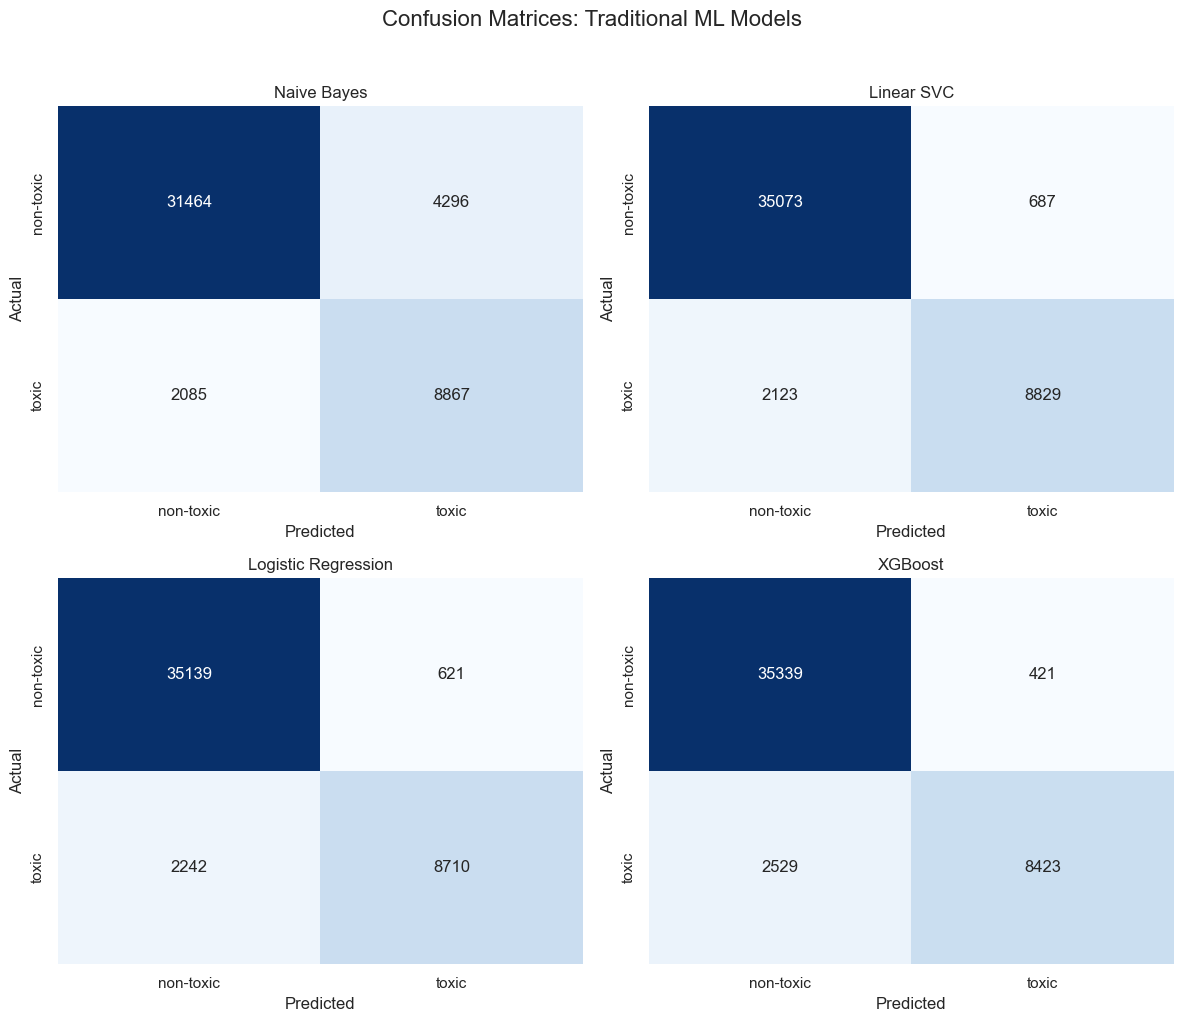

In [ ]:
plot_confusion_matrices(classical_results, "Confusion Matrices: Traditional ML Models", cols=2)

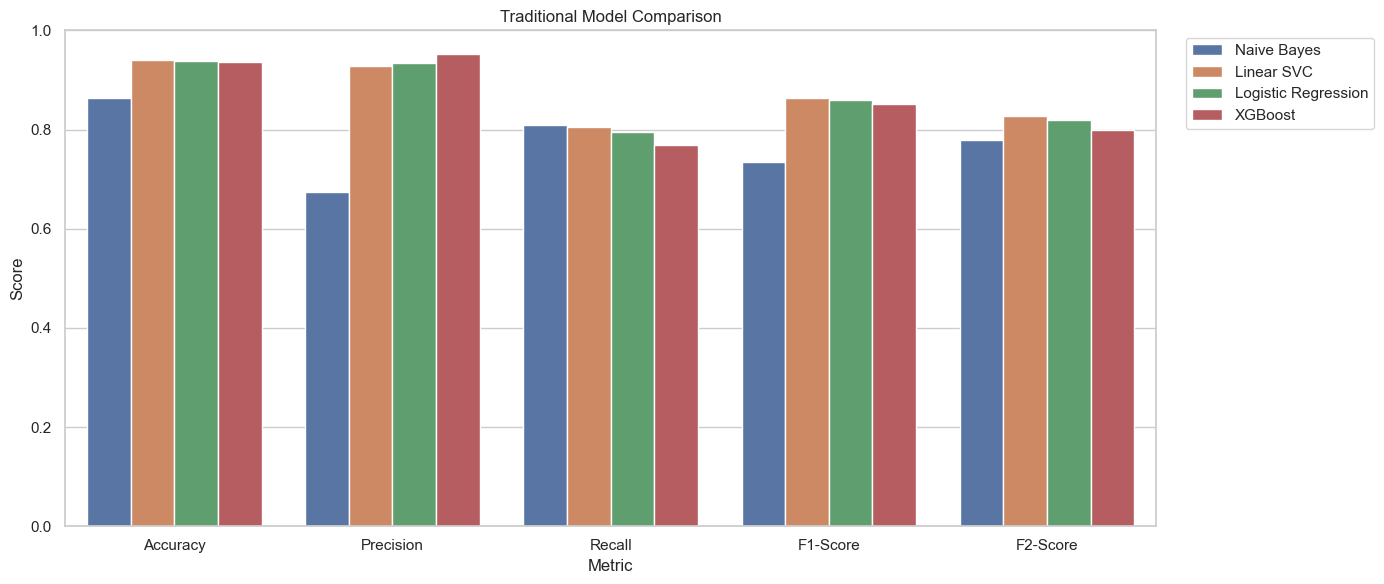

In [ ]:
metric_cols = ["Accuracy", "Precision", "Recall", "F1-Score", "F2-Score"]
melted = classical_results_df.melt(id_vars="Model", value_vars=metric_cols, var_name="Metric", value_name="Score")

plt.figure(figsize=(14, 6))
sns.barplot(data=melted, x="Metric", y="Score", hue="Model")
plt.ylim(0, 1.0)
plt.title("Traditional Model Comparison")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Recall-Oriented Traditional Variants

The project docs mention three techniques to improve toxic recall:
- `class_weight='balanced'`
- oversampling
- threshold tuning

This section keeps those experiments in the combined notebook as optional recall-focused variants.


In [ ]:
svc_balanced = Pipeline(
    [
        ("vect", TfidfVectorizer(tokenizer=word_tokenize, ngram_range=NGRAM_RANGE, min_df=5)),
        ("clf", LinearSVC(class_weight="balanced", random_state=RANDOM_STATE)),
    ]
)

lr_balanced = Pipeline(
    [
        ("vect", TfidfVectorizer(tokenizer=word_tokenize, ngram_range=NGRAM_RANGE, min_df=5)),
        ("clf", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE)),
    ]
)

svc_oversampled = ImbPipeline(
    [
        ("vect", TfidfVectorizer(tokenizer=word_tokenize, ngram_range=NGRAM_RANGE, min_df=5)),
        ("over", RandomOverSampler(random_state=RANDOM_STATE)),
        ("clf", LinearSVC(random_state=RANDOM_STATE)),
    ]
)

recall_variant_models = {
    "Linear SVC (Balanced)": svc_balanced,
    "Logistic Regression (Balanced)": lr_balanced,
    "Linear SVC (Oversampled)": svc_oversampled,
}

recall_variant_results = []
recall_variant_fitted = {}

for model_name, model in recall_variant_models.items():
    metrics, fitted_model = train_or_load_baseline_model(
        model_name,
        model,
        X_train,
        y_train,
        X_test,
        y_test,
        force_retrain=False,
    )
    recall_variant_results.append(metrics)
    recall_variant_fitted[model_name] = fitted_model

threshold_probs = fitted_classical_models["Logistic Regression"].predict_proba(X_test)[:, 1]
threshold_preds = (threshold_probs >= 0.4).astype(int)
threshold_metrics = compute_metrics(y_test, threshold_preds)
threshold_metrics["Model"] = "Logistic Regression (Threshold 0.4)"
threshold_metrics["confusion_matrix"] = confusion_matrix(y_test, threshold_preds)
recall_variant_results.append(threshold_metrics)

recall_variant_df = (
    pd.DataFrame(recall_variant_results)
    .drop(columns=["confusion_matrix"])
    .sort_values(by=["Recall", "F2-Score", "F1-Score"], ascending=False)
    .reset_index(drop=True)
)
recall_variant_df

Linear SVC (Balanced) | model cache: False | meta cache: False | force_retrain=False
Training baseline: Linear SVC (Balanced)
Logistic Regression (Balanced) | model cache: False | meta cache: False | force_retrain=False
Training baseline: Logistic Regression (Balanced)
Linear SVC (Oversampled) | model cache: False | meta cache: False | force_retrain=False
Training baseline: Linear SVC (Oversampled)


,Accuracy,Precision,Recall,F1-Score,F2-Score,Model
0,0.938453,0.848898,0.897188,0.872375,0.887095,Logistic Regression (Balanced)
1,0.942627,0.869220,0.889061,0.879029,0.885021,Linear SVC (Balanced)
2,0.942606,0.874558,0.881665,0.878098,0.880235,Linear SVC (Oversampled)
3,0.941000,0.896325,0.846238,0.870562,0.855803,Logistic Regression (Threshold 0.4)


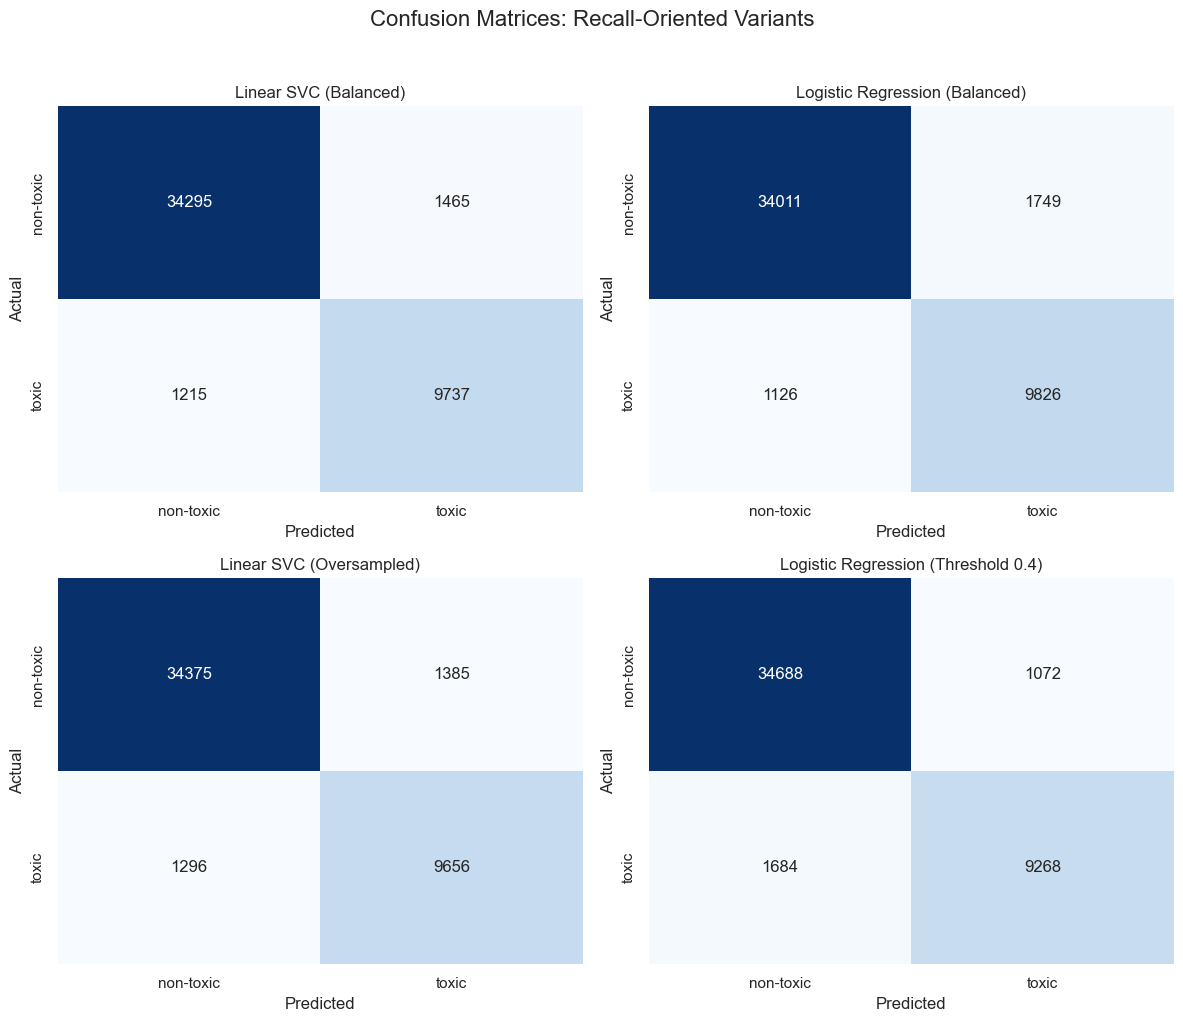

In [ ]:
plot_confusion_matrices(recall_variant_results, "Confusion Matrices: Recall-Oriented Variants", cols=2)


## Transformer Models

Models:
- WangchanBERTa
- PhayaThaiBERT

Notes:
- The docs identify WangchanBERTa as the selected model for the overall system.
- A threshold of around `0.3-0.4` can improve toxic recall during moderation, so this notebook evaluates transformer outputs with `0.4` by default.


In [ ]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    MAX_LENGTH = 128
    BATCH_SIZE = 16
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    MAX_LENGTH = 96
    BATCH_SIZE = 16
else:
    device = torch.device("cpu")
    MAX_LENGTH = 64
    BATCH_SIZE = 8

print("Device:", device)
print("MAX_LENGTH:", MAX_LENGTH)
print("BATCH_SIZE:", BATCH_SIZE)

Device: mps
MAX_LENGTH: 96
BATCH_SIZE: 16


In [ ]:
class ToxicityDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            add_special_tokens=True,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(int(self.labels[idx]), dtype=torch.long),
        }


def get_label_weights(labels):
    labels = np.asarray(labels)
    counts = np.bincount(labels, minlength=2)
    weights = counts.sum() / (len(counts) * counts)
    return torch.tensor(weights, dtype=torch.float)


class_weights = get_label_weights(y_train)
class_weights

tensor([0.6531, 2.1327])

In [ ]:
def get_transformer_cache_paths(model_name):
    safe_name = get_safe_name(model_name)
    model_dir = TRANSFORMER_CACHE_DIR / safe_name
    meta_path = model_dir / "metadata.json"
    return model_dir, meta_path


def train_epoch(model, dataloader, optimizer, scheduler, device, class_weights):
    model.train()
    total_loss = 0.0
    loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights.to(device))

    for batch in tqdm(dataloader, desc="Training", leave=False):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = loss_fn(outputs.logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

    return total_loss / max(len(dataloader), 1)


def evaluate_transformer(model, dataloader, device, threshold=0.4):
    model.eval()
    total_loss = 0.0
    preds = []
    probs = []
    labels_all = []
    loss_fn = torch.nn.CrossEntropyLoss()

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating", leave=False):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            loss = loss_fn(logits, labels)
            total_loss += loss.item()

            toxic_probs = F.softmax(logits, dim=1)[:, 1]
            batch_preds = (toxic_probs >= threshold).long()

            probs.extend(toxic_probs.cpu().numpy())
            preds.extend(batch_preds.cpu().numpy())
            labels_all.extend(labels.cpu().numpy())

    return {
        "loss": total_loss / max(len(dataloader), 1),
        "predictions": np.array(preds),
        "probabilities": np.array(probs),
        "labels": np.array(labels_all),
    }


def train_and_evaluate_transformer(
    model_name,
    model_id,
    X_train,
    y_train,
    X_test,
    y_test,
    threshold=0.4,
    force_retrain=False,
):
    model_dir, meta_path = get_transformer_cache_paths(model_name)

    if model_dir.exists() and meta_path.exists() and not force_retrain:
        print("=" * 90)
        print(f"Loading cached {model_name} from {model_dir}")
        print("=" * 90)

        with open(meta_path, "r", encoding="utf-8") as f:
            metadata = json.load(f)

        if "wangchanberta" in model_id.lower():
            tokenizer = CamembertTokenizer.from_pretrained(model_dir)
        else:
            tokenizer = AutoTokenizer.from_pretrained(model_dir, trust_remote_code=True)

        model = AutoModelForSequenceClassification.from_pretrained(
            model_dir,
            trust_remote_code=True,
        )
        model.to(device)

        final_metrics = metadata["metrics"]
        final_metrics["confusion_matrix"] = np.array(final_metrics["confusion_matrix"])
        final_metrics["history"] = pd.DataFrame(metadata.get("history", []))

        trained_objects = {
            "model": model,
            "tokenizer": tokenizer,
            "threshold": metadata.get("threshold", threshold),
            "model_dir": str(model_dir),
            "loaded_from_cache": True,
        }

        return final_metrics, trained_objects

    print("=" * 90)
    print(f"Training {model_name}: {model_id}")
    print("=" * 90)

    if "wangchanberta" in model_id.lower():
        tokenizer = CamembertTokenizer.from_pretrained(model_id)
    else:
        tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_id,
        num_labels=2,
        trust_remote_code=True,
    )
    model.to(device)

    train_dataset = ToxicityDataset(X_train, y_train, tokenizer, MAX_LENGTH)
    test_dataset = ToxicityDataset(X_test, y_test, tokenizer, MAX_LENGTH)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
    total_steps = len(train_loader) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=min(WARMUP_STEPS, total_steps // 10 if total_steps else 0),
        num_training_steps=total_steps,
    )

    best_state_dict = None
    best_f2 = -1.0
    history = []

    for epoch in range(EPOCHS):
        train_loss = train_epoch(model, train_loader, optimizer, scheduler, device, class_weights)
        eval_output = evaluate_transformer(model, test_loader, device, threshold=threshold)
        epoch_f2 = fbeta_score(eval_output["labels"], eval_output["predictions"], beta=2, zero_division=0)

        history.append(
            {
                "epoch": epoch + 1,
                "train_loss": train_loss,
                "eval_loss": eval_output["loss"],
                "f2": epoch_f2,
            }
        )

        print(
            f"Epoch {epoch + 1}/{EPOCHS} | "
            f"train_loss={train_loss:.4f} | eval_loss={eval_output['loss']:.4f} | f2={epoch_f2:.4f}"
        )

        if epoch_f2 > best_f2:
            best_f2 = epoch_f2
            best_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)
        model.to(device)

    final_eval = evaluate_transformer(model, test_loader, device, threshold=threshold)
    final_metrics = compute_metrics(final_eval["labels"], final_eval["predictions"])
    final_metrics["Model"] = model_name
    final_metrics["Threshold"] = threshold
    final_metrics["confusion_matrix"] = confusion_matrix(final_eval["labels"], final_eval["predictions"])
    final_metrics["history"] = pd.DataFrame(history)

    print(classification_report(final_eval["labels"], final_eval["predictions"], target_names=CLASS_NAMES, zero_division=0))

    model_dir.mkdir(parents=True, exist_ok=True)
    model.save_pretrained(model_dir)
    tokenizer.save_pretrained(model_dir)

    metadata = {
        "model_name": model_name,
        "model_id": model_id,
        "threshold": threshold,
        "metrics": {
            "Model": final_metrics["Model"],
            "Accuracy": final_metrics["Accuracy"],
            "Precision": final_metrics["Precision"],
            "Recall": final_metrics["Recall"],
            "F1-Score": final_metrics["F1-Score"],
            "F2-Score": final_metrics["F2-Score"],
            "Threshold": final_metrics["Threshold"],
            "confusion_matrix": final_metrics["confusion_matrix"].tolist(),
        },
        "history": history,
    }

    with open(meta_path, "w", encoding="utf-8") as f:
        json.dump(metadata, f, ensure_ascii=False, indent=2)

    trained_objects = {
        "model": model,
        "tokenizer": tokenizer,
        "threshold": threshold,
        "model_dir": str(model_dir),
        "loaded_from_cache": False,
    }

    return final_metrics, trained_objects

In [ ]:
transformer_results = []
trained_transformers = {}

for model_name, model_id in TRANSFORMER_MODELS.items():
    result, trained_object = train_and_evaluate_transformer(
        model_name,
        model_id,
        X_train.tolist(),
        y_train.tolist(),
        X_test.tolist(),
        y_test.tolist(),
        threshold=TRANSFORMER_THRESHOLD,
        force_retrain=False,
    )
    transformer_results.append(result)
    trained_transformers[model_name] = trained_object

    if device.type == "cuda":
        torch.cuda.empty_cache()
    elif device.type == "mps":
        torch.mps.empty_cache()
    gc.collect()

transformer_results_df = (
    pd.DataFrame(transformer_results)
    .drop(columns=["confusion_matrix", "history"])
    .sort_values(by=["Recall", "F2-Score", "F1-Score"], ascending=False)
    .reset_index(drop=True)
)
transformer_results_df

Training WangchanBERTa: airesearch/wangchanberta-base-att-spm-uncased


Some weights of CamembertForSequenceClassification were not initialized from the model checkpoint at airesearch/wangchanberta-base-att-spm-uncased and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Training:   0%|          | 0/11678 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
plot_confusion_matrices(transformer_results, "Confusion Matrices: Transformer Models", cols=2)

In [ ]:
transformer_metric_cols = ["Accuracy", "Precision", "Recall", "F1-Score", "F2-Score"]
transformer_melted = transformer_results_df.melt(
    id_vars="Model",
    value_vars=transformer_metric_cols,
    var_name="Metric",
    value_name="Score",
)

plt.figure(figsize=(14, 6))
sns.barplot(data=transformer_melted, x="Metric", y="Score", hue="Model")
plt.ylim(0, 1.0)
plt.title("Transformer Model Comparison")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
combined_results_df = pd.concat(
    [
        classical_results_df.assign(Group="Traditional"),
        transformer_results_df.assign(Group="Transformer"),
    ],
    ignore_index=True,
).sort_values(by=["Recall", "F2-Score", "F1-Score"], ascending=False)

combined_results_df

## Inference Helper

The helper below uses the selected transformer model, returns:
- predicted label
- toxic score
- confidence
- moderation action recommendation

Recommended moderation policy from the docs:
- `HIDE` when toxic score is above threshold
- `ALLOW` otherwise

You can switch `SELECTED_MODEL_NAME` if you prefer another trained transformer after comparison.


In [ ]:
SELECTED_MODEL_NAME = "Logistic Regression (Balanced)"

if SELECTED_MODEL_NAME in trained_transformers:
    selected_bundle = trained_transformers[SELECTED_MODEL_NAME]
    selected_model_type = "transformer"
elif SELECTED_MODEL_NAME in recall_variant_fitted:
    selected_bundle = recall_variant_fitted[SELECTED_MODEL_NAME]
    selected_model_type = "classical"
elif SELECTED_MODEL_NAME in fitted_classical_models:
    selected_bundle = fitted_classical_models[SELECTED_MODEL_NAME]
    selected_model_type = "classical"
else:
    raise KeyError(f"{SELECTED_MODEL_NAME} not found")


def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def preprocess_for_inference(text):
    return lowercase_english(clean_text(text))


def predict_toxicity(text, bundle=selected_bundle, model_type=selected_model_type, threshold=0.4):
    processed = preprocess_for_inference(text)

    if model_type == "transformer":
        model = bundle["model"]
        tokenizer = bundle["tokenizer"]
        threshold = bundle["threshold"]

        model.eval()

        encoded = tokenizer(
            processed,
            add_special_tokens=True,
            max_length=MAX_LENGTH,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )

        encoded = {key: value.to(device) for key, value in encoded.items()}

        with torch.no_grad():
            logits = model(**encoded).logits
            toxic_score = F.softmax(logits, dim=1)[0, 1].item()

    else:
        model = bundle

        if hasattr(model, "predict_proba"):
            toxic_score = float(model.predict_proba([processed])[0][1])
        elif hasattr(model, "decision_function"):
            decision = float(model.decision_function([processed])[0])
            toxic_score = float(sigmoid(decision))
        else:
            pred = int(model.predict([processed])[0])
            toxic_score = 1.0 if pred == 1 else 0.0

    predicted_label = int(toxic_score >= threshold)
    confidence = toxic_score if predicted_label == 1 else 1 - toxic_score

    return {
        "text": text,
        "processed_text": processed,
        "predicted_label": "toxic" if predicted_label == 1 else "non-toxic",
        "toxic_score": round(float(toxic_score), 4),
        "confidence": round(float(confidence), 4),
        "threshold": threshold,
        "action": "HIDE" if predicted_label == 1 else "ALLOW",
        "model_name": SELECTED_MODEL_NAME,
        "model_type": model_type,
    }


sample_texts = [
    "ข้อความนี้แย่มากและควรถูกลบ",
    "ขอบคุณมากครับ วันนี้ช่วยได้เยอะเลย",
    "this comment is extremely toxic and hateful",
    "ควาย",
    "กระจอก",
    "shit",
    "Noob",
    "เลิกพูดอะไรไร้สาระแบบนี้ได้แล้ว",
    "เห็นด้วยมาก ข้อมูลมีประโยชน์จริงๆ",
    "มึงโง่มาก",
    "บริการดีมาก ประทับใจสุดๆ",
    "You are so stupid",
    "Thanks for sharing this, very helpful",
    "คำพูดแบบนี้มันแย่มาก",
    "น่ารักมากเลยครับ",
    "ไอ้ขยะ",
    "ผลงานดีขึ้นเยอะเลย สู้ๆ",
    "This is garbage",
    "I really appreciate your effort",
    "คนแบบมึงไม่ควรพูดอะไรเลย",
    "วันนี้อากาศดีนะ",
    "หยุดเห่าได้แล้ว",
    "Well explained and easy to understand",
    "โคตรงี่เง่า",
    "บทความนี้เขียนดีมาก",
    "What a useless comment",
    "ขอบคุณสำหรับคำแนะนำครับ",
    "ปัญญาอ่อน",
    "You did a great job",
    "เลวมาก",
    "เนื้อหานี้มีประโยชน์กับฉันมาก",
    "Trash opinion",
    "ช่วยอธิบายได้ชัดเจนมาก",
    "ห่วยแตก",
    "This was kind and thoughtful",
    "ไอ้สัส",
    "สุดยอดมากครับ ชอบไอเดียนี้",
    "pathetic loser",
    "ขอให้วันนี้เป็นวันที่ดีนะ",
    "มึงมันกระจอก",
    "That was a respectful response",
]

pd.DataFrame([predict_toxicity(text) for text in sample_texts])

,text,processed_text,predicted_label,toxic_score,confidence,threshold,action,model_name,model_type
0,ข้อความนี้แย่มากและควรถูกลบ,ข้อความนี้แย่มากและควรถูกลบ,toxic,0.4218,0.4218,0.4,HIDE,Logistic Regression (Balanced),classical
1,ขอบคุณมากครับ วันนี้ช่วยได้เยอะเลย,ขอบคุณมากครับ วันนี้ช่วยได้เยอะเลย,non-toxic,0.1996,0.8004,0.4,ALLOW,Logistic Regression (Balanced),classical
2,this comment is extremely toxic and hateful,this comment is extremely toxic and hateful,non-toxic,0.2702,0.7298,0.4,ALLOW,Logistic Regression (Balanced),classical
3,ควาย,ควาย,toxic,0.7788,0.7788,0.4,HIDE,Logistic Regression (Balanced),classical
4,กระจอก,กระจอก,non-toxic,0.2269,0.7731,0.4,ALLOW,Logistic Regression (Balanced),classical
5,shit,shit,toxic,1.0000,1.0000,0.4,HIDE,Logistic Regression (Balanced),classical
6,Noob,noob,non-toxic,0.3514,0.6486,0.4,ALLOW,Logistic Regression (Balanced),classical
7,เลิกพูดอะไรไร้สาระแบบนี้ได้แล้ว,เลิกพูดอะไรไร้สาระแบบนี้ได้แล้ว,toxic,0.5486,0.5486,0.4,HIDE,Logistic Regression (Balanced),classical
8,เห็นด้วยมาก ข้อมูลมีประโยชน์จริงๆ,เห็นด้วยมาก ข้อมูลมีประโยชน์จริงๆ,toxic,0.6210,0.6210,0.4,HIDE,Logistic Regression (Balanced),classical
9,มึงโง่มาก,มึงโง่มาก,toxic,0.8229,0.8229,0.4,HIDE,Logistic Regression (Balanced),classical
